Steps in Data Analysis for data cases
1. Define the objective
2. Data Understanding and Collection: Descriptive staistics and visualizations. Identify issues like missing values or outliers.
   This step ensures the data aligns with your objective.
3. Data Preparation: Normalize scales, encode categorical variables, and merge datasets
4. Identify Dependent and Independent Variables: Correlation
5. Develop Model, Analysis & Validation
6. Evaluation and Insights (Inferences & Datastory telling)
7. Suggestions & Data-driven decisions
8. Conclusion

Objective: To improve sales revenue and increase customer retention

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_excel("/Users/aaravdinesh/Documents/Python/work/Online Retail Data Set.xlsx")
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [3]:
data['Sales'] = data['Quantity'] * data['UnitPrice']
data.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [4]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Sales
count,541909.000000,541909,541909.000000,406829.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,17.987795
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,218.081158,NaN,96.759853,1713.600303,378.810824


In [5]:
data.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


<Axes: >

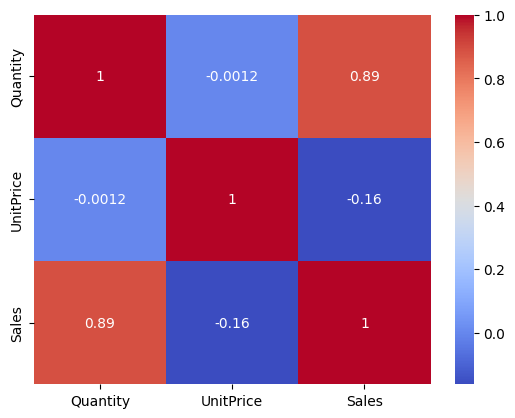

In [6]:
corr_map = sns.heatmap(data[['Quantity','UnitPrice','Sales']].corr(), annot=True, cmap='coolwarm')
corr_map

In [7]:
x = data[['UnitPrice']]
y = data[['Sales']]

In [8]:
x_train,x_test,y_train,y_test, = train_test_split(x,y,test_size=0.2, random_state=42)

In [9]:
model = LinearRegression()
model = model.fit(x_train,y_train)
rsquared = model.score(x,y)
intercept = model.coef_[0]
list(zip(x, model.coef_))
y_pred = model.predict(x_test)

Text(0.5, 1.0, 'Actual vs Predicted')

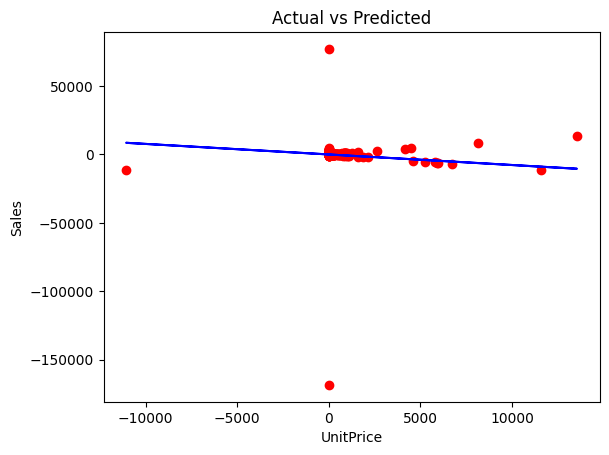

In [10]:
plt.scatter(x_test,y_test,color='red',label='Actual line')
plt.plot(x_test, y_pred, color='blue', label='Predicted line')
plt.xlabel('UnitPrice')
plt.ylabel('Sales')
plt.title('Actual vs Predicted')

In [11]:
#prescriptive analytics
from scipy.optimize import linprog

In [12]:
selling_price = 500
cost_price = 300
profit_per_unit = selling_price - cost_price

In [13]:
c = [profit_per_unit]

In [14]:
# Constraints: Quantity <= 1000
A = [[1]]
b = [1000]

In [15]:
# Quantity >= 0
bounds = [(0,None)]

In [16]:
# Optimization
result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

In [17]:
optimal_quantity = result.x[0]
maximum_profit = profit_per_unit * optimal_quantity

In [18]:
print("Optimal Quantity to Sell:", optimal_quantity)
print("Maximum Profit:", maximum_profit)

Optimal Quantity to Sell: 0.0
Maximum Profit: 0.0


In [20]:
from datetime import timedelta

In [21]:
data = data.dropna(subset=["CustomerID"]) # Remove missing customers
data = data[data['Quantity']>0] # Remove returns
data = data[data['UnitPrice']>0] # Remove zero price

In [23]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['CustomerID'] = data['CustomerID'].astype(int)

In [25]:
#Total Amount
data['TotalAmount'] = data['Quantity'] * data['UnitPrice']

In [26]:
analysis_date = data['InvoiceDate'].max() + timedelta(days=1)

In [28]:
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x:(analysis_date - x.max()).days, #Recency
    'InvoiceNo': 'nunique', # Frequency
    'TotalAmount': 'sum' # Monetary

}).reset_index()
rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

In [29]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4])

In [31]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)+
    rfm['F_Score'].astype(str)+
    rfm['M_Score'].astype(str))

In [32]:
def segment_customer(row):
    if row['RFM_Score'] >= '444':
        return 'Champions'
    elif row['RFM_Score'] >= '344':
        return 'Loyal Customers'
    elif row['RFM_Score'] >= '244':
        return 'Potential Loyalists'
    elif row['RFM_Score'] >= '144':
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [33]:
print(rfm.head())

   CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
0       12346      326          1  77183.60       1       1       4       114   
1       12347        2          7   4310.00       4       4       4       444   
2       12348       75          4   1797.24       2       3       4       234   
3       12349       19          1   1757.55       3       1       4       314   
4       12350      310          1    334.40       1       1       2       112   

               Segment  
0       Lost Customers  
1            Champions  
2              At Risk  
3  Potential Loyalists  
4       Lost Customers  


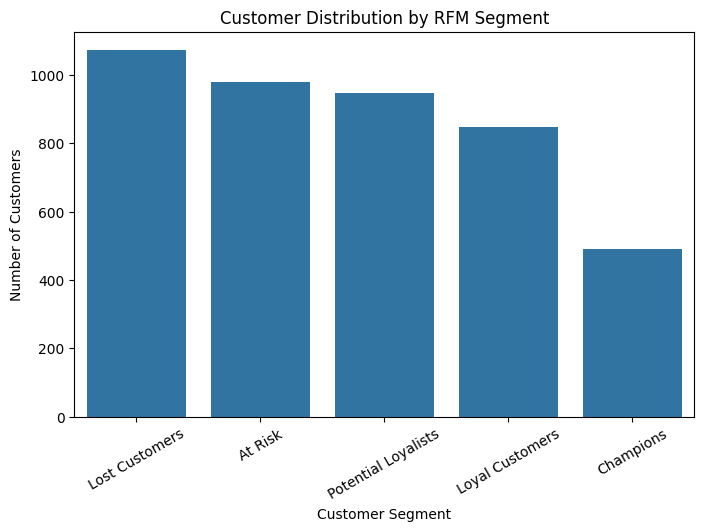

In [34]:
plt.figure(figsize=(8,5))
sns.countplot(x='Segment', data=rfm, order=rfm['Segment'].value_counts().index)
plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

In [35]:
new_retail = pd.read_csv("/Users/aaravdinesh/Documents/Python/work/new_retail_data.csv")
new_retail.head(10)

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies
5,6095326.0,41289.0,Ryan Johnson,Haley12@gmail.com,3.292677e+09,532 Ashley Crest Suite 014,Brisbane,New South Wales,74430.0,Australia,...,1185.167224,Electronics,Apple,Tablet,Good,Express,PayPal,Pending,4.0,Lenovo Tab
6,5434096.0,97285.0,Erin Lewis,Arthur76@gmail.com,1.578355e+09,600 Brian Prairie Suite 497,Kitchener,Ontario,47545.0,Canada,...,630.115295,Electronics,Samsung,Television,Bad,Standard,Cash,Processing,1.0,QLED TV
7,2344675.0,26603.0,Angela Fields,Tanya94@gmail.com,3.668096e+09,237 Young Curve,Munich,Berlin,86862.0,Germany,...,46.588070,Clothing,Zara,Shirt,Bad,Same-Day,Cash,Processing,1.0,Dress shirt
8,4155845.0,80175.0,Diane Clark,Martin39@gmail.com,6.219780e+09,8823 Mariah Heights Apt. 263,Wollongong,New South Wales,39820.0,Australia,...,2630.714413,Grocery,Nestle,Chocolate,Bad,Same-Day,Cash,Delivered,1.0,Dark chocolate
9,4926148.0,31878.0,Lori Bell,Jessica33@gmail.com,6.004895e+09,6225 William Lodge,Cologne,Berlin,64317.0,Germany,...,3976.112295,Home Decor,Home Depot,Decorations,Excellent,Standard,Cash,Delivered,4.0,Candles


In [36]:
new_retail.describe()

,Transaction_ID,Customer_ID,Phone,Zipcode,Age,Year,Total_Purchases,Amount,Total_Amount,Ratings
count,3.016770e+05,301702.000000,3.016480e+05,301670.000000,301837.000000,301660.000000,301649.000000,301653.000000,301660.000000,301826.000000
mean,5.495823e+06,55006.553934,5.501464e+09,50298.951019,35.481326,2023.165113,5.359729,255.163659,1367.651156,3.162670
std,2.595565e+06,26005.675200,2.596017e+09,28972.807134,15.021933,0.371283,2.868575,141.389640,1128.998515,1.320827
min,1.000007e+06,10000.000000,1.000049e+09,501.000000,18.000000,2023.000000,1.000000,10.000219,10.003750,1.000000
25%,3.247930e+06,32469.250000,3.255061e+09,25425.000000,22.000000,2023.000000,3.000000,132.890764,438.724278,2.000000
50%,5.499657e+06,55012.000000,5.505812e+09,50602.500000,32.000000,2023.000000,5.000000,255.470969,1041.117547,3.000000
75%,7.739509e+06,77511.000000,7.749860e+09,75252.000000,46.000000,2023.000000,8.000000,377.672606,2029.999853,4.000000
max,9.999995e+06,99999.000000,9.999996e+09,99949.000000,70.000000,2024.000000,10.000000,499.997911,4999.625796,5.000000


Objective: To find out if ratings can be improved and customer retention is increased.

<Axes: >

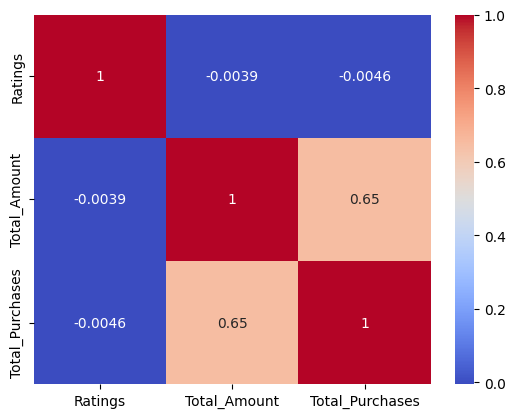

In [37]:
sns.heatmap(new_retail[['Ratings', 'Total_Amount', 'Total_Purchases']].corr(),annot=True, cmap='coolwarm')

In [38]:
x = new_retail[['Total_Amount','Total_Purchases']]
y = new_retail[['Ratings']]

In [39]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model= LinearRegression()
model = model.fit(x,y)
list(zip(x, model.coef_))


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/aaravdinesh/Documents/Python/work/Mall_Customers.csv")

In [3]:
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
print(df.info(
))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [5]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [6]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


<Axes: >

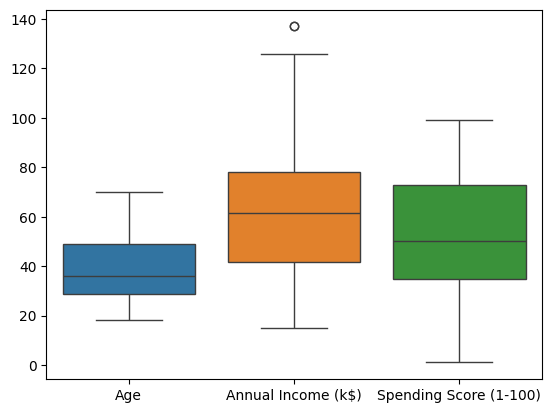

In [7]:
plt.figure()
sns.boxplot(data=df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])

THe median age is around 38 years old, with the highest age being around 70 years old and the lowest being 19. There is a huge variation in the ages of customers

In [8]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

features = df[['Gender','Age','Annual Income (k$)', 'Spending Score (1-100)']]

#Normalize
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

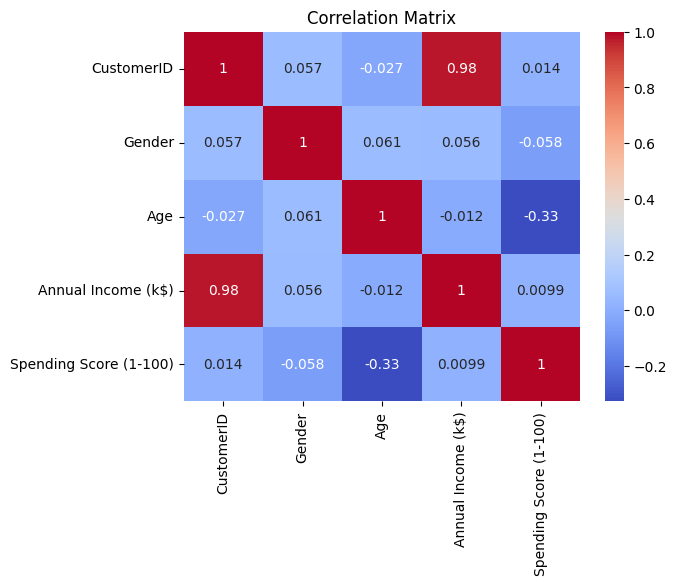

In [9]:
plt.figure()
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

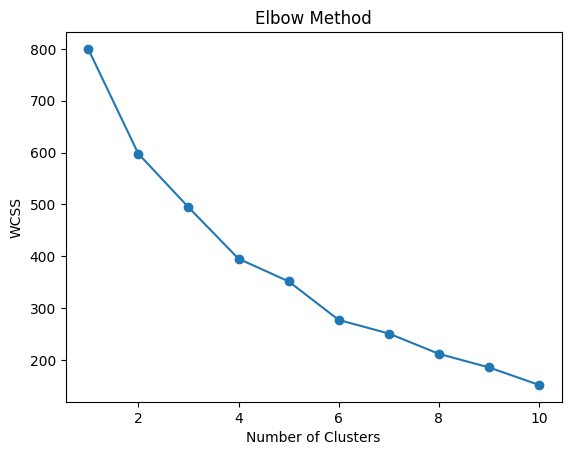

In [10]:
from sklearn.cluster import KMeans 

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)
plt.figure()
plt.plot(range(1,11),wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [11]:
# Apply KMeans with optimal clusters
kmeans = KMeans(n_clusters=5, random_state=42)
df['Segment'] = kmeans.fit_predict(scaled_features)

In [12]:
demographic = df.groupby('Segment')[['Age','Gender']].mean()
print(demographic)

               Age    Gender
Segment                     
0        56.470588  0.509804
1        39.500000  1.000000
2        28.690476  1.000000
3        37.897959  0.000000
4        27.315789  0.000000
